In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Download Stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
#Load dataset
df = pd.read_csv("train.csv")

In [4]:
print(df.shape)

df.head()

(20800, 5)


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [5]:
#Handle missing value
df = df.fillna('')

In [6]:
#Create content column
df['content'] = df['author'] + ' ' + df['title']

In [7]:
#Test Preprocessing
port_stem = PorterStemmer()

In [8]:
def stemming(content):

    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)

    stemmed_content = stemmed_content.lower()

    stemmed_content = stemmed_content.split()

    stemmed_content = [
        port_stem.stem(word)
        for word in stemmed_content
        if word not in stopwords.words('english')
    ]

    stemmed_content = ' '.join(stemmed_content)

    return stemmed_content

In [9]:
df['content'] = df['content'].apply(stemming)

In [10]:
#Seperate features and label
X = df['content']

y = df['label']

In [11]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [12]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Logistic Regression

In [13]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [14]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.973798076923077


In [15]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2132
           1       0.96      0.99      0.97      2028

    accuracy                           0.97      4160
   macro avg       0.97      0.97      0.97      4160
weighted avg       0.97      0.97      0.97      4160



In [ ]:
#Naive Bayes

In [16]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [17]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9533653846153847


In [18]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2132
           1       1.00      0.91      0.95      2028

    accuracy                           0.95      4160
   macro avg       0.96      0.95      0.95      4160
weighted avg       0.96      0.95      0.95      4160



In [19]:
#Model Comparision
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [lr_accuracy, nb_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.973798
1,Naive Bayes,0.953365


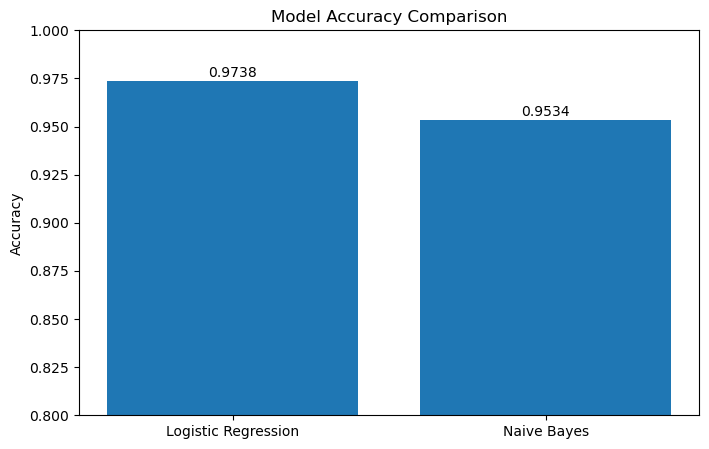

In [20]:
#Accuracy Bar chart
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8,1.0)

for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.show()

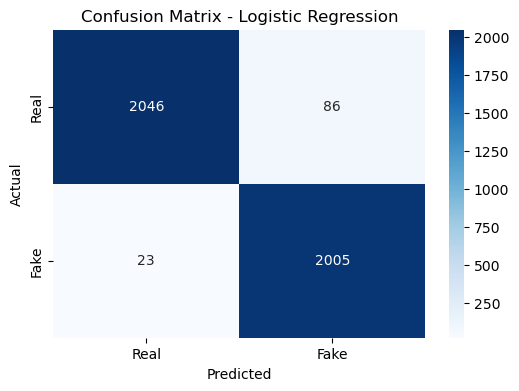

In [21]:
#Confusion matrix(Logistics regression)
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

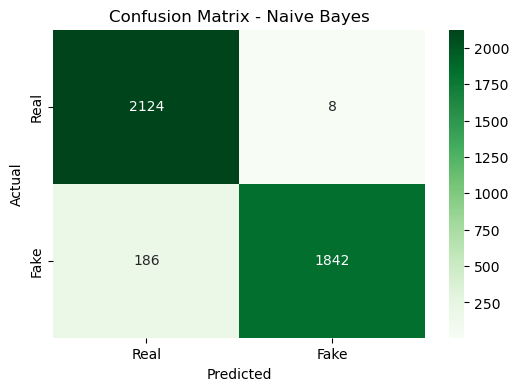

In [22]:
#Confusion matrix(NB)
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')

plt.show()

In [23]:
news = [
    "Breaking News Government announces new tax reforms"
]

news_vector = vectorizer.transform(news)

prediction = lr_model.predict(news_vector)

if prediction[0] == 0:
    print("Real News")
else:
    print("Fake News")

Real News
